In [1]:
from keras.layers import *
from keras.models import Model

I0000 00:00:1790320627.251683    6037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790320627.391483    6037 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790320629.228568    6037 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790320698.588914    6037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [4]:
inputA = Input(shape=(32,))
inputB = Input(shape=(128,))

In [6]:
# the first branch operates on the first input

x = Dense(8, activation='relu')(inputA)
x1 = Dense(4,activation='relu')(x)

In [7]:
# the second branch opreates on the second input
y = Dense(64, activation="relu")(inputB)
y1 = Dense(32, activation="relu")(y)
y2 = Dense(4, activation="relu")(y1)

In [8]:
# combine the output of the two branches
combined = concatenate([x1, y2])

In [9]:
# apply a FC layer and then a regression prediction on the
# combined outputs
z = Dense(2, activation="relu")(combined)
z1 = Dense(1, activation="linear")(z)

In [11]:
# our model will accept the inputs of the two branches and
# then output a single value

model = Model(inputs=[inputA,inputB],outputs=z1)

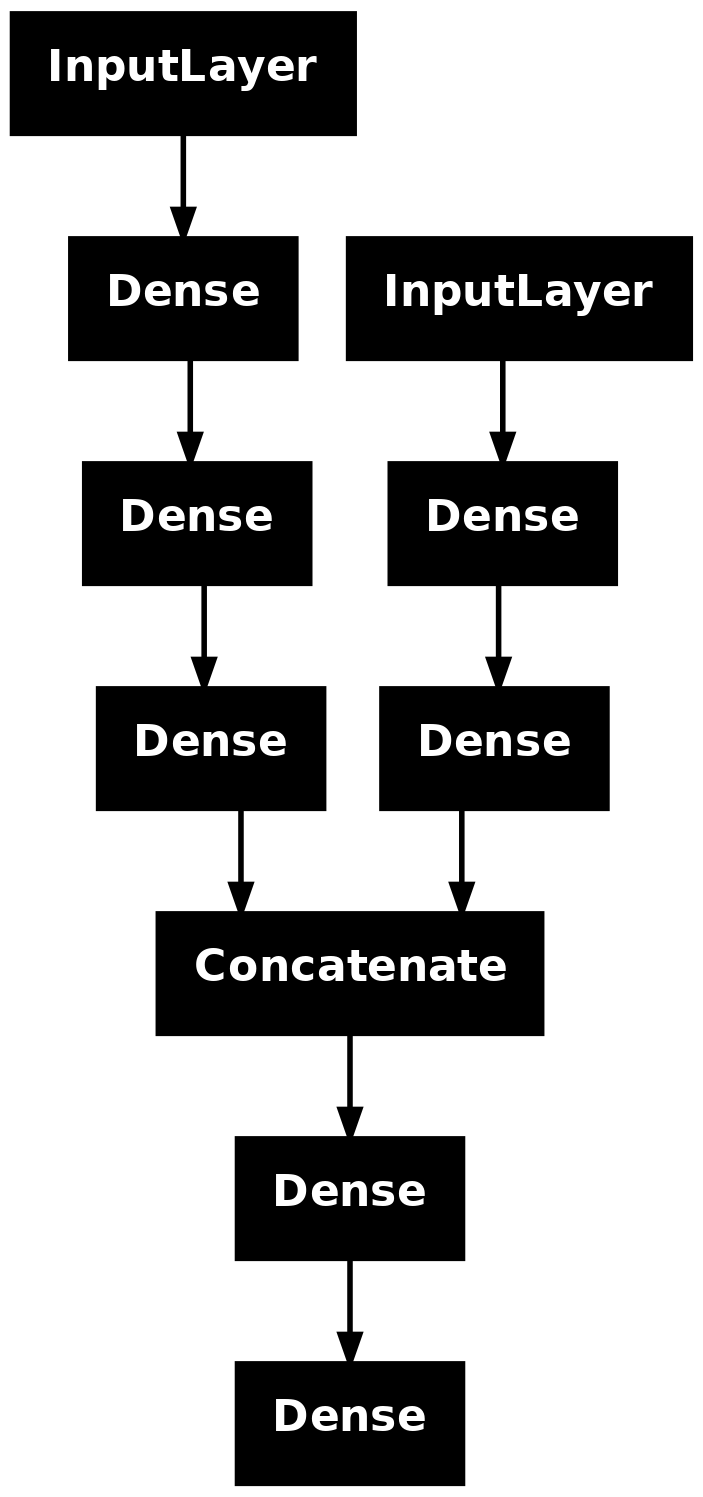

In [14]:
from keras.utils import plot_model
plot_model(model)